In [1]:
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LabelGuard benchmark

In [16]:
def map_models(x):
    if x["params.max_depth"] is not None:
        return "xgboost"
    if x["params.lr"] is not None:
        return "mlp"
    if x["params.solver"] is not None:
        return "logreg"
    if x["params.kernel"] is not None:
        return "svm"
    return "unkown"

In [17]:
EXPERIMENT_NAME = "LabelGuard"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
PARAMS_COL = [
    # Logreg ou SVM
    "C",
    # XGBoost
    "max_depth",
    "n_estimators",
    # MLP
    "hidden_layers",
    "dropout_layers",
    "lr"
]

METRICS_COL = [
    "eval_accuracy",
    "eval_f1",
    "eval_fpr",
    "train_accuracy",
    "train_f1",
    "train_fpr"
]

columns_to_keep = ["params." + param for param in PARAMS_COL] + ["metrics." + metric for metric in METRICS_COL]

df_paper = df_runs[columns_to_keep].copy()
df_paper.columns = [col.replace("params.", "").replace("metrics.", "") for col in df_paper.columns]

# 3. Trier par la meilleure performance
df_paper = df_paper.sort_values(by="eval_fpr", ascending=True)

# 4. Optionnel : Arrondir les métriques pour l'affichage
df_paper[METRICS_COL] = df_paper[METRICS_COL].round(4)

df_paper["model"] = df_runs.apply(map_models, axis=1)

# Affichage du tableau propre
df_paper.to_csv("labelguard_benchmark.csv", index=False)

## Baseline benchmark

In [2]:
EXPERIMENT_NAME = "benchmark-baseline"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
# Removing the last 2 runs which were retraining because of mlflow model db loss
df_runs = df_runs.tail(36).reset_index(drop=True)

In [3]:
PARAMS_COL = [
    "input_data.preprocessed",
    "model.embedding_dim",
    "lr"
]

METRICS_COL = [
    "test_accuracy_top1",
    "test_accuracy_top5",
    "confidence_coverage_rate",
    "confidence_accuracy"
]

columns_to_keep = ["params." + param for param in PARAMS_COL] + ["metrics." + metric for metric in METRICS_COL]

df_paper = df_runs[columns_to_keep].copy()
df_paper.columns = [col.replace("params.", "").replace("metrics.", "") for col in df_paper.columns]

# 3. Trier par la meilleure performance
df_paper = df_paper.sort_values(by="test_accuracy_top1", ascending=False)

# 4. Optionnel : Arrondir les métriques pour l'affichage
df_paper[METRICS_COL] = df_paper[METRICS_COL].round(4)

df_paper = df_paper.rename(columns={
    "input_data.preprocessed" : "Text preprocessing",
    "model.embedding_dim" : "Embedding dimension",
    "lr": "Learning Rate",
    "test_accuracy_top1": "Test Accuracy - Top 1",
    "test_accuracy_top5": "Test Accuracy - Top 5",
    "confidence_coverage_rate": "Confidence Coverage Rate",
    "confidence_accuracy": "Confidence Accuracy"
})

# Affichage du tableau propre
df_paper.to_csv("baseline_benchmark.csv", index=False)

## Synthetic benchmark

In [4]:
EXPERIMENT_NAME = "benchmark-evaluation-level4"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

In [5]:
PARAMS_COL = [
    "source_synth_name",
    "source_synth_split",
]

METRICS_COL = [
    # Accuracy Top 1
    "lvl4_acc_top1",
    "lvl4_head_acc_top1",
    "lvl4_body_acc_top1",
    "lvl4_tail_acc_top1",
    "lvl5_acc_top1",
    "lvl5_head_acc_top1",
    "lvl5_body_acc_top1",
    "lvl5_tail_acc_top1",

    # Accuracy Top 5
    "lvl4_acc_top5",
    "lvl4_head_acc_top5",
    "lvl4_body_acc_top5",
    "lvl4_tail_acc_top5",
    "lvl5_acc_top5",
    "lvl5_head_acc_top5",
    "lvl5_body_acc_top5",
    "lvl5_tail_acc_top5",

    # Confidence coverage rate
    "lvl4_coverage_rate",
    "lvl4_head_coverage_rate",
    "lvl4_body_coverage_rate",
    "lvl4_tail_coverage_rate",
    "lvl5_coverage_rate",
    "lvl5_head_coverage_rate",
    "lvl5_body_coverage_rate",
    "lvl5_tail_coverage_rate",

    # Confidence accuracy
    "lvl4_acc_confident",
    "lvl4_head_acc_confident",
    "lvl4_body_acc_confident",
    "lvl4_tail_acc_confident",
    "lvl5_acc_confident",
    "lvl5_head_acc_confident",
    "lvl5_body_acc_confident",
    "lvl5_tail_acc_confident"
]

columns_to_keep = ["params." + param for param in PARAMS_COL] + ["metrics." + metric for metric in METRICS_COL]

df_graphs = df_runs[columns_to_keep].copy()

In [24]:
import re

df_graphs.columns = [col.replace("params.", "").replace("metrics.", "") for col in df_graphs.columns]
df_graphs["source_synth_split"] = df_graphs["source_synth_split"].astype(float)

dataset_map_name = {
    "retext1_exhaustive": "Code2ReText generation (exhaustive)",
    "retext1_distrib": "Code2ReText generation (close to the original distribution)",
    "naive_exhaustive": "Naive Code2Text generation (exhaustive)",
    "baseline": "Original training dataset"
}

def format_metric_name(metric_str: str) -> str:
    """
    Formate un nom de métrique MLflow brut en une légende propre en anglais.
    Exemple: 'lvl4_head_acc_top5' -> 'Lvl 4 (Head) - Accuracy Top 5'
             'lvl5_coverage_rate'   -> 'Lvl 5 (All) - Coverage Rate'
    """
    # 1. Extraire le niveau (lvl4 ou lvl5)
    level_match = re.search(r"lvl(\d)", metric_str)
    level_text = f"Level {level_match.group(1)}" if level_match else ""
    
    # 2. Extraire la tranche de la distribution (head, body, tail)
    # Si aucune n'est mentionnée, c'est que ça concerne toute la distribution ("All")
    split_text = "All"
    if "_head_" in metric_str:
        split_text = "Head"
    elif "_body_" in metric_str:
        split_text = "Body"
    elif "_tail_" in metric_str:
        split_text = "Tail"
        
    # 3. Identifier le type de métrique et formater proprement
    if "acc_top1" in metric_str:
        metric_type = "Accuracy Top 1"
    elif "acc_top5" in metric_str:
        metric_type = "Accuracy Top 5"
    elif "coverage_rate" in metric_str:
        metric_type = "Coverage Rate"
    elif "acc_confident" in metric_str:
        metric_type = "Confidence Accuracy"
    else:
        # Fallback au cas où le nom ne match pas
        metric_type = metric_str.replace("_", " ").title()

    # 4. Assembler le tout dans un format standardisé style papier
    return f"{level_text} ({split_text}) - {metric_type}"

metric_map_name = {m: format_metric_name(m) for m in METRICS_COL}
map_names = metric_map_name.copy()
map_names.update(dataset_map_name)
map_names.update({
    "source_synth_split": "Proportion of Synthetic Data",
    "source_synth_name": "Source of the Synthetic Data Part"
})

In [ ]:
baseline_row = df_graphs[df_graphs["source_synth_name"] == "baseline"].iloc[0]

other_names = [name for name in df_graphs["source_synth_name"].unique() if name != "baseline"]

new_rows = []
for name in other_names:
    new_row = baseline_row.copy()
    new_row["source_synth_name"] = name
    new_row["source_synth_split"] = 0
    new_rows.append(new_row)

df_new_baselines = pd.DataFrame(new_rows)
df_filtered = df_graphs[df_graphs["source_synth_name"] != "baseline"]
df_graphs = pd.concat([df_filtered, df_new_baselines], ignore_index=True)

In [80]:
def export_plot(df_graphs, x, y):
    df_graphs = df_graphs.sort_values(by=["source_synth_name", x])

    fig, ax = plt.subplots(figsize=(12, 5))

    markers = ['o', 's', 'D', '^']

    grouped = df_graphs.groupby("source_synth_name")
    for i, (name, group) in enumerate(grouped):
        clean_name = map_names.get(name, name)
        
        marker_style = markers[i % len(markers)]
        
        ax.plot(
            group[x], 
            group[y], 
            label=clean_name,
            marker=marker_style,
            markersize=7,
            linewidth=1.5
        )

    ax.set_xlabel(map_names.get(x, x), fontsize=11)
    ax.set_ylabel(map_names.get(y, y), fontsize=11)

    ax.grid(True, which='both', color='lightgray', linestyle=':', linewidth=1)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    legend = ax.legend(
        loc='best',
        frameon=True,
        facecolor='white',

    )

    plt.tight_layout()
    plt.savefig(f"compare_datasets/{x}_vs_{y}.png")

/tmp/ipykernel_78073/1725772373.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12, 5))


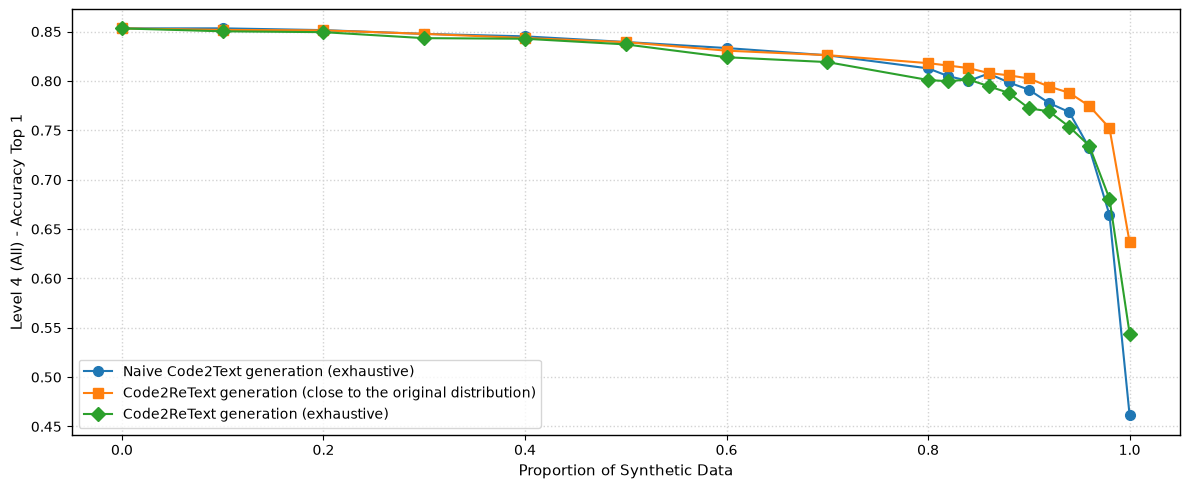

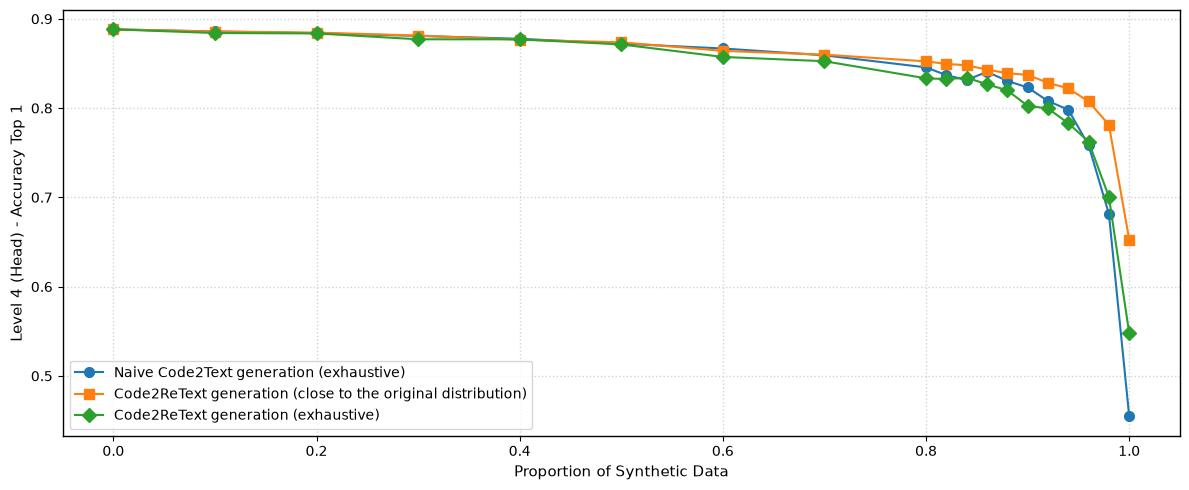

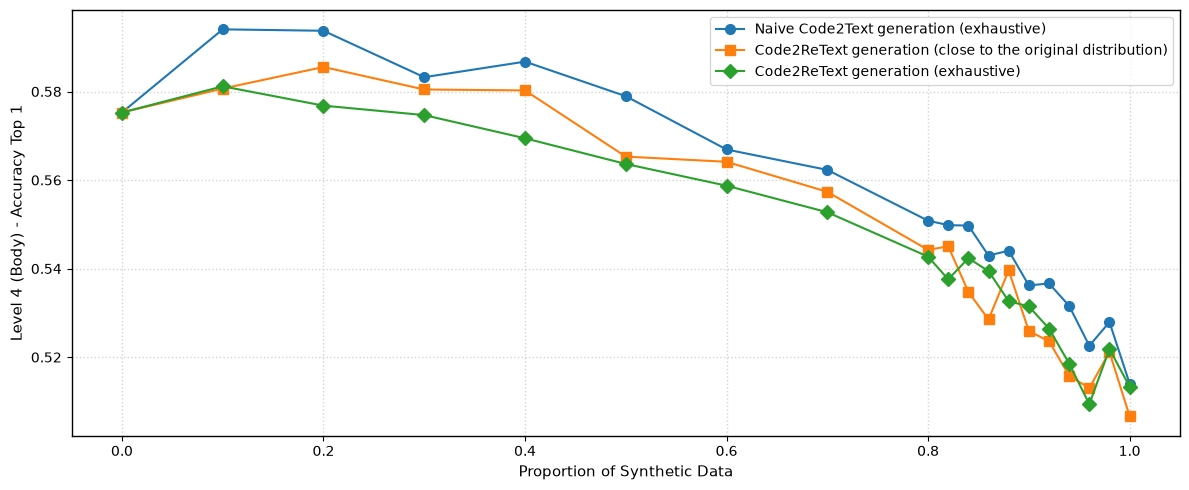

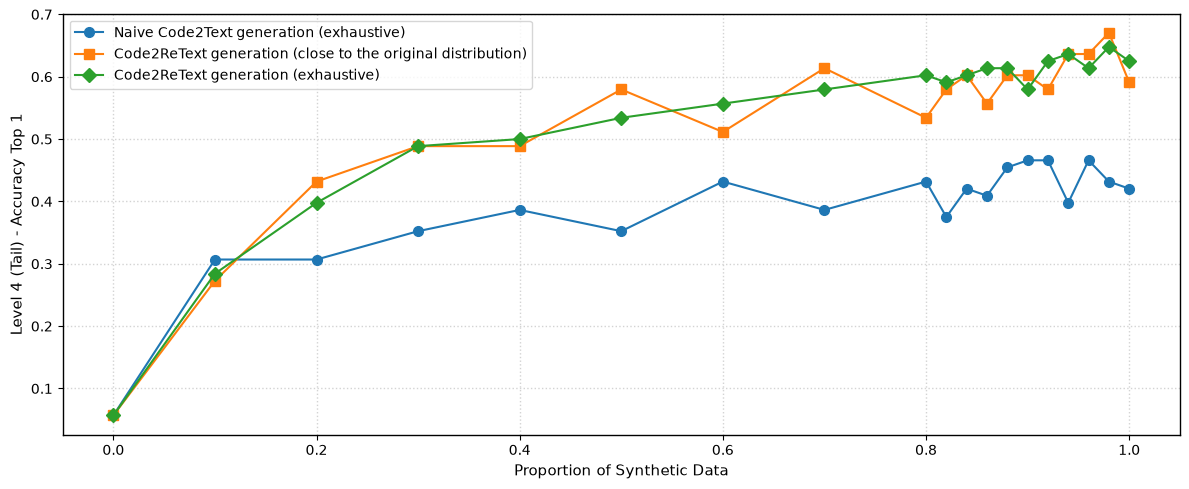

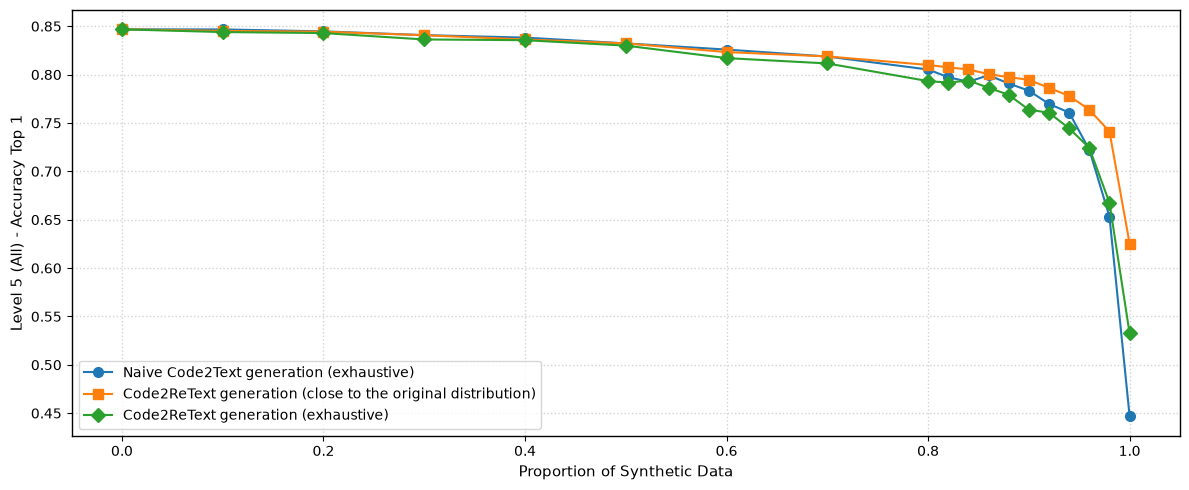

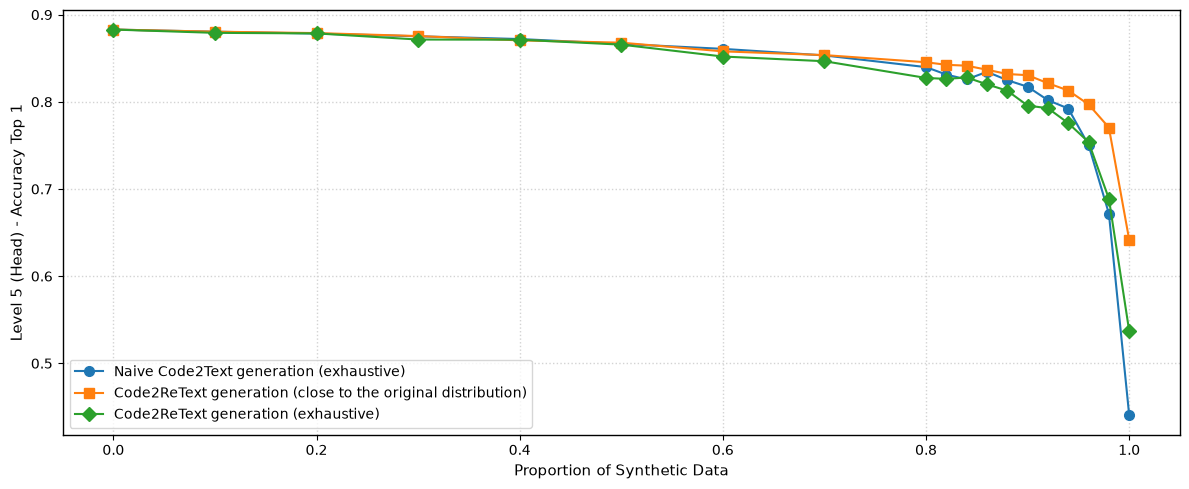

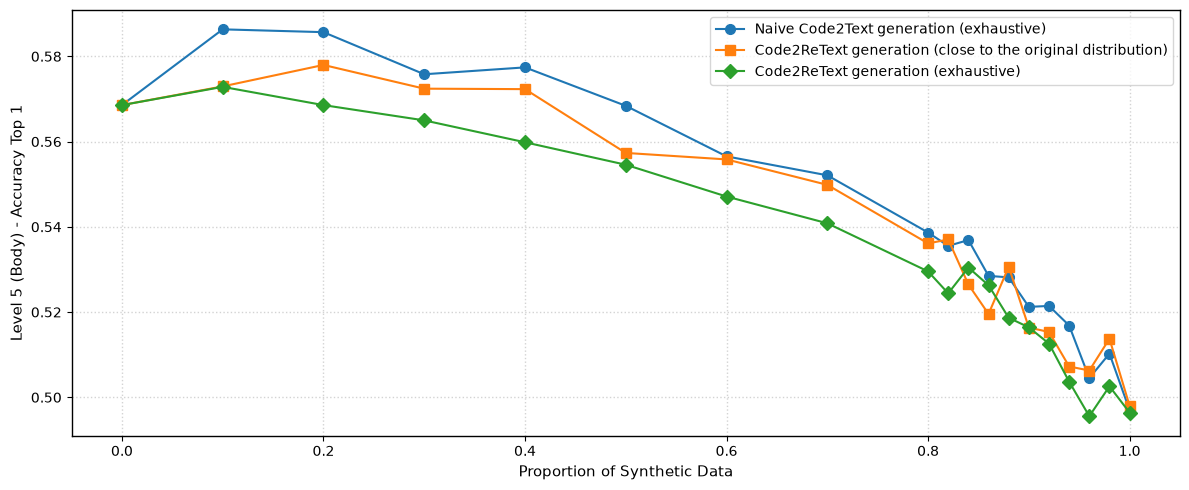

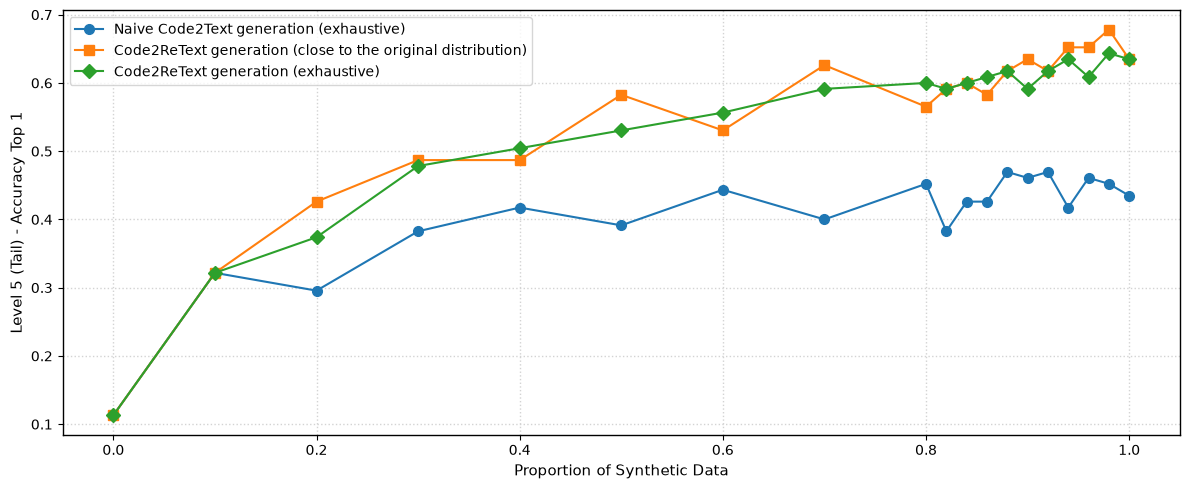

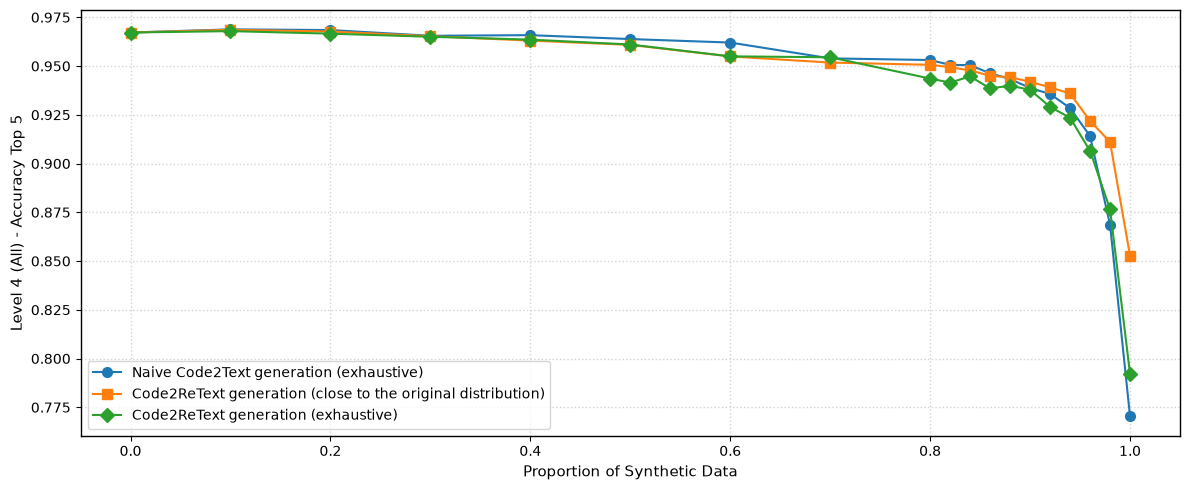

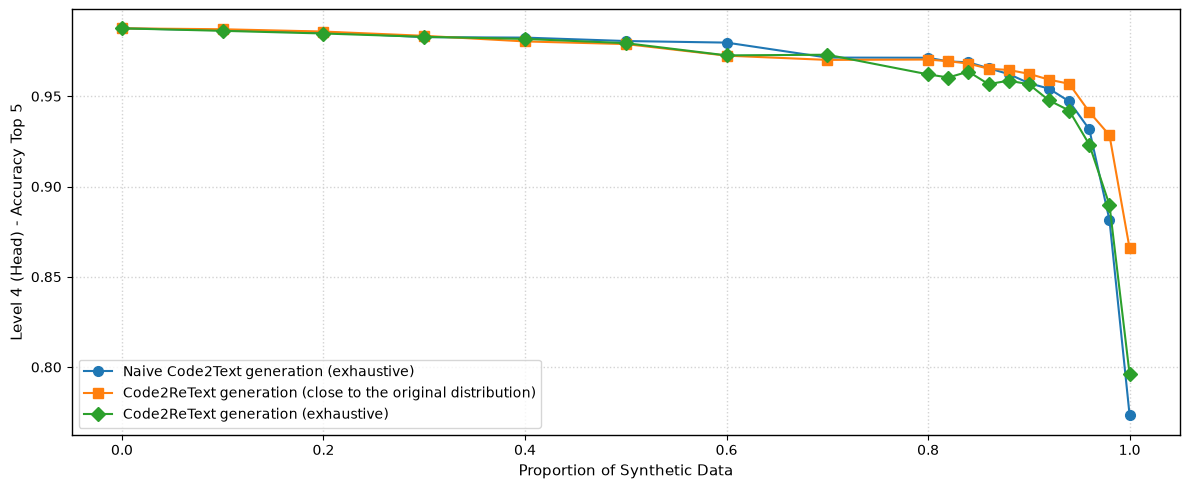

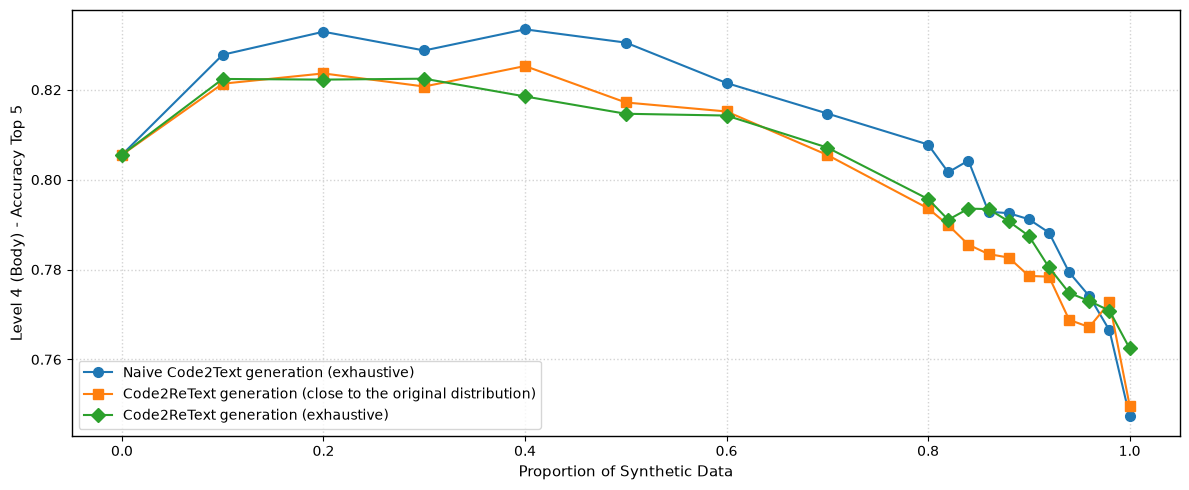

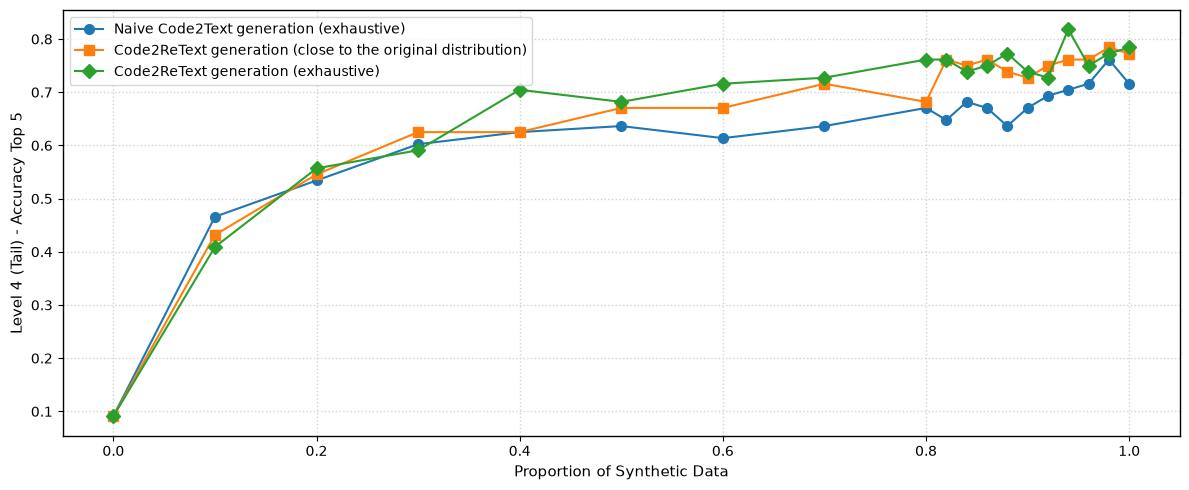

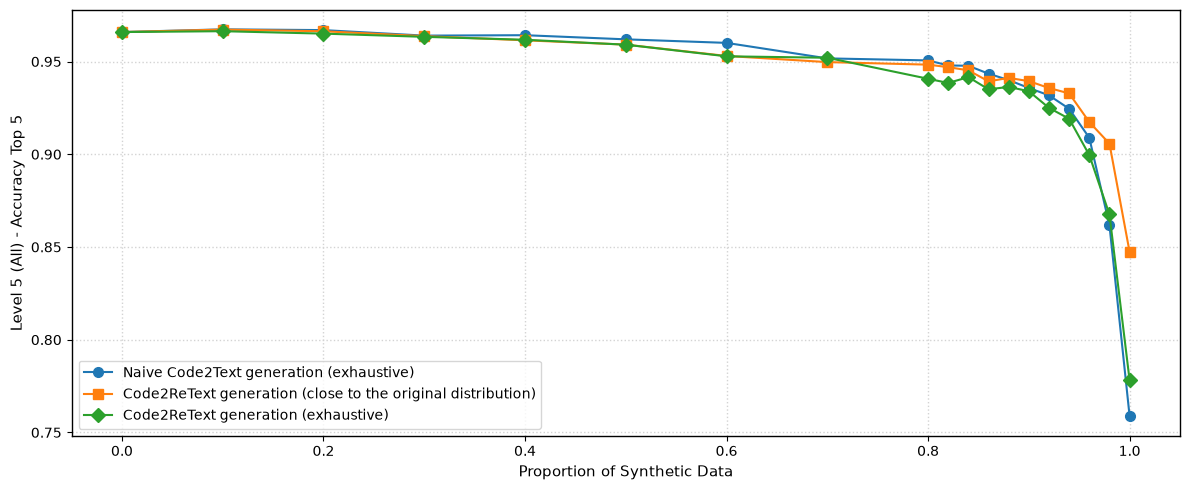

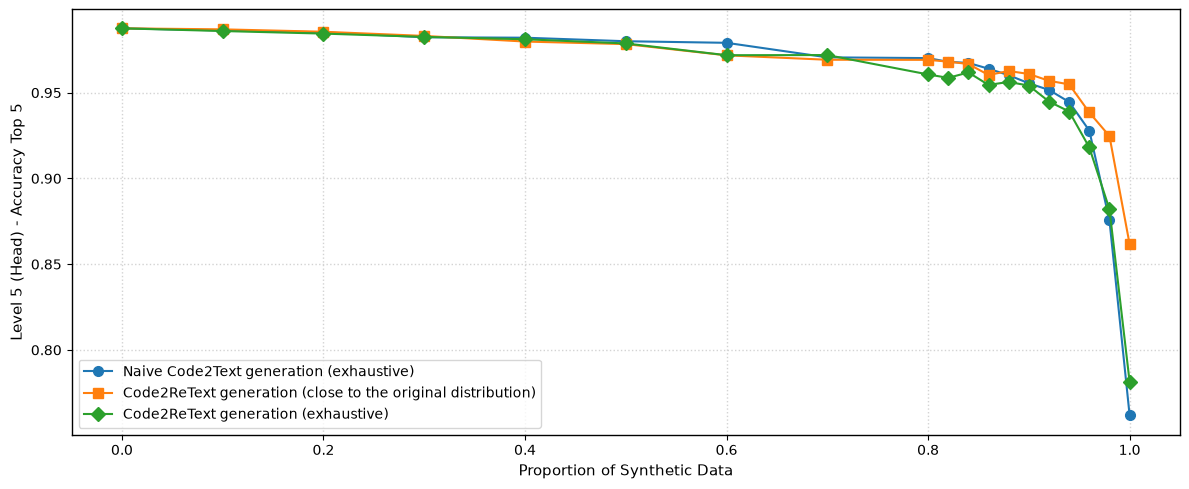

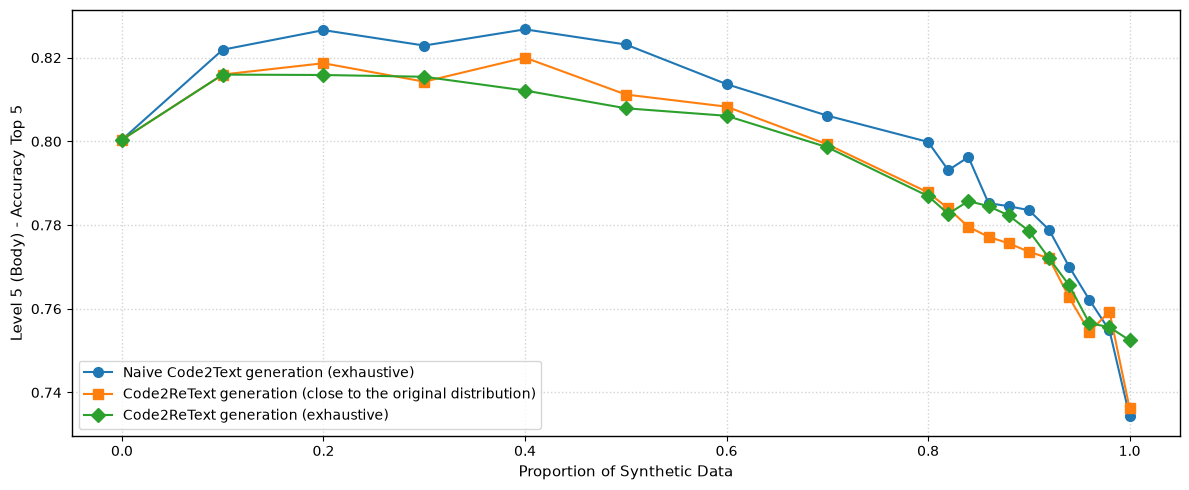

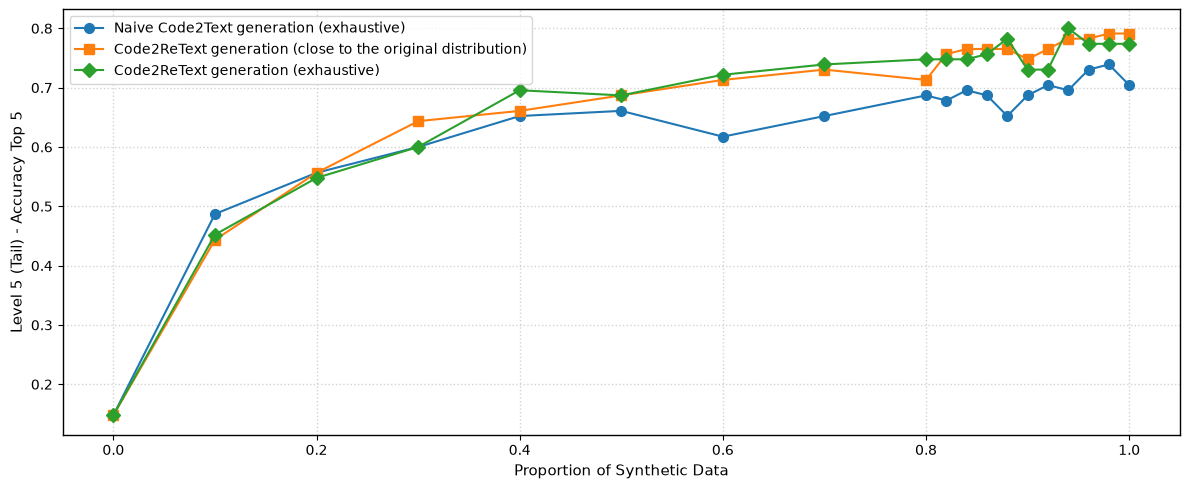

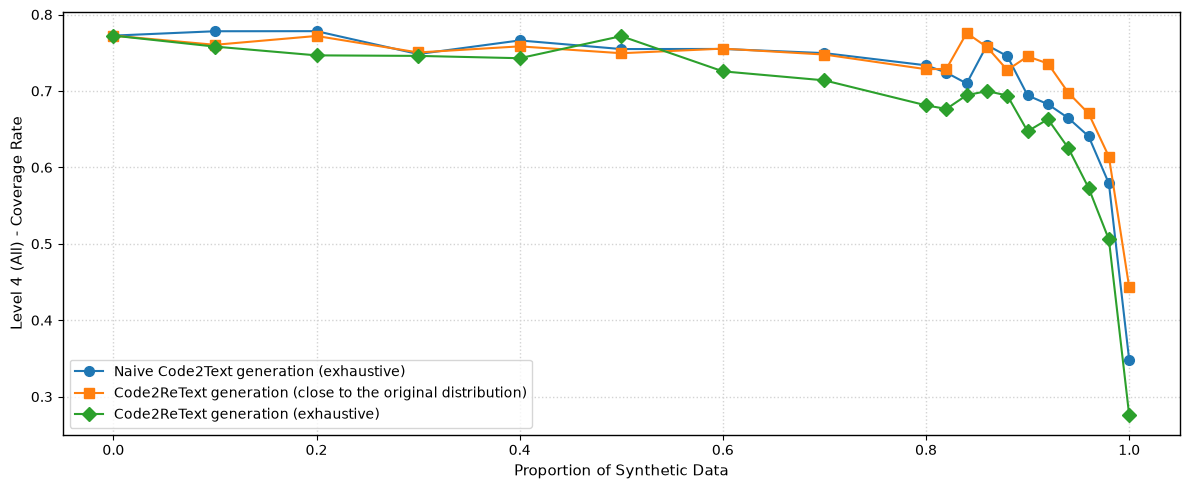

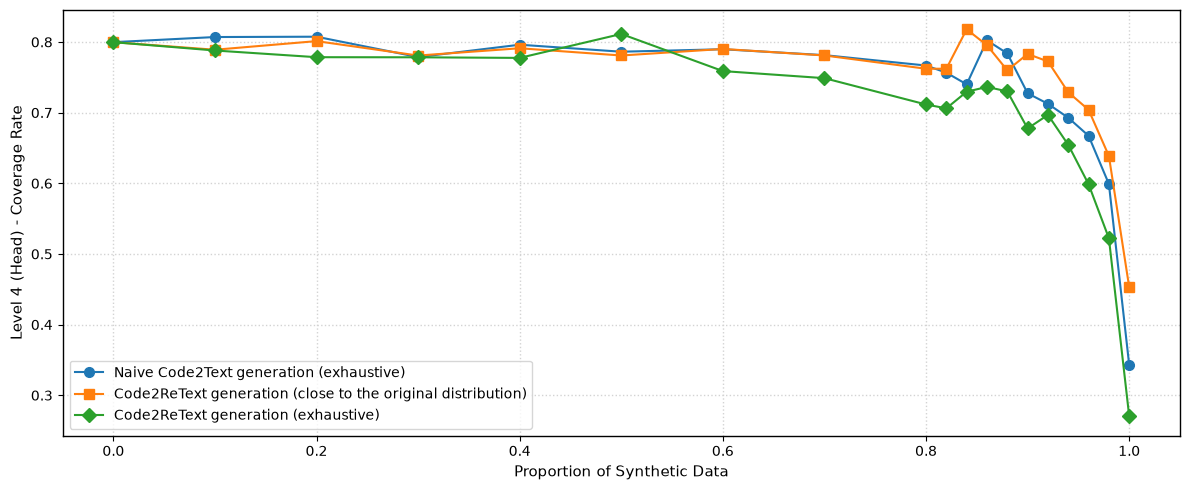

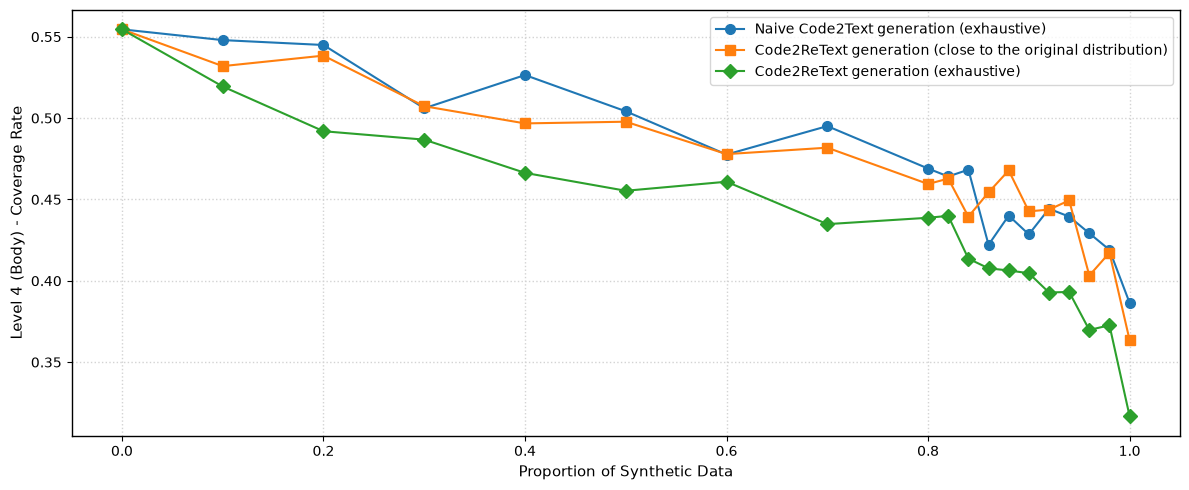

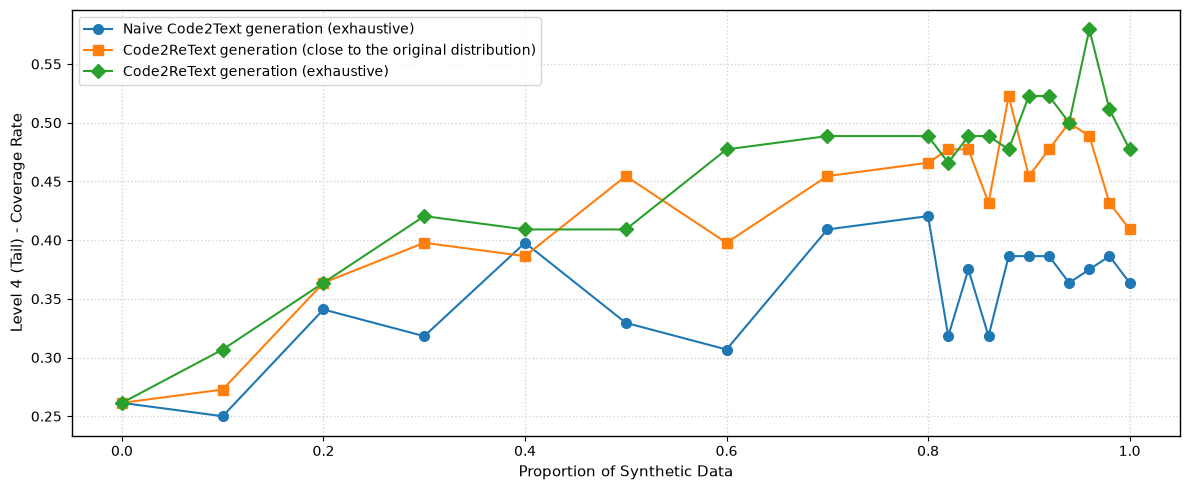

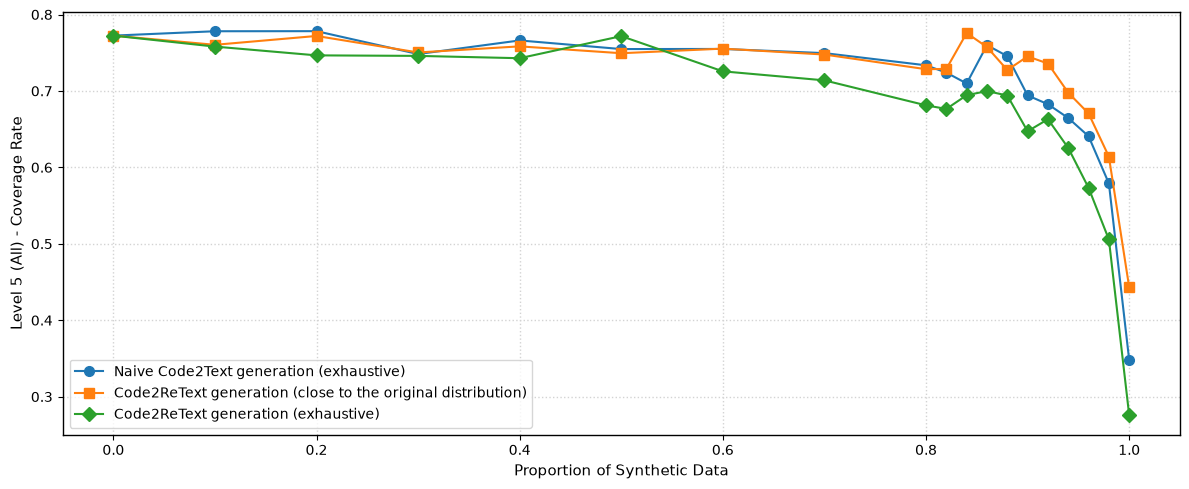

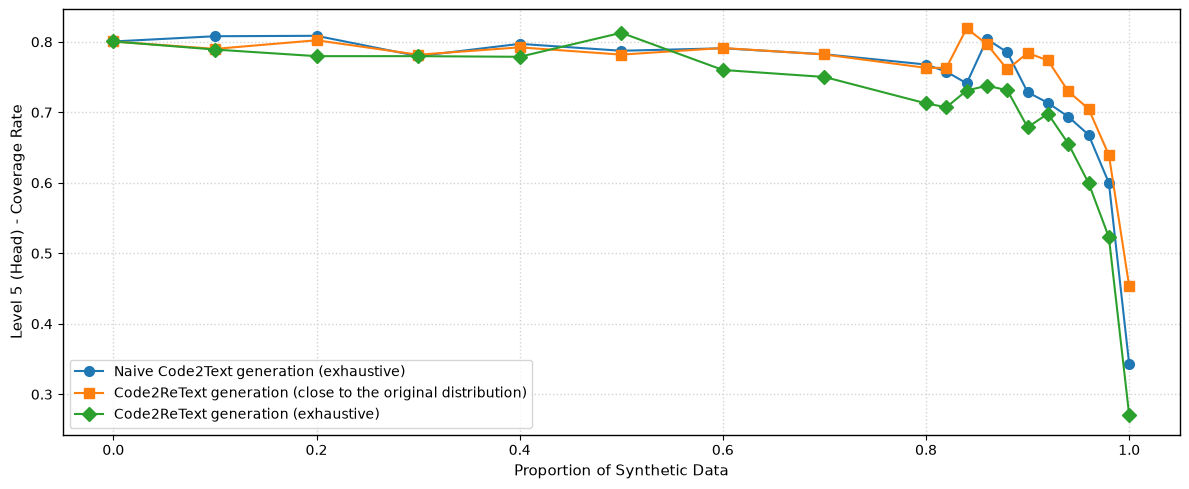

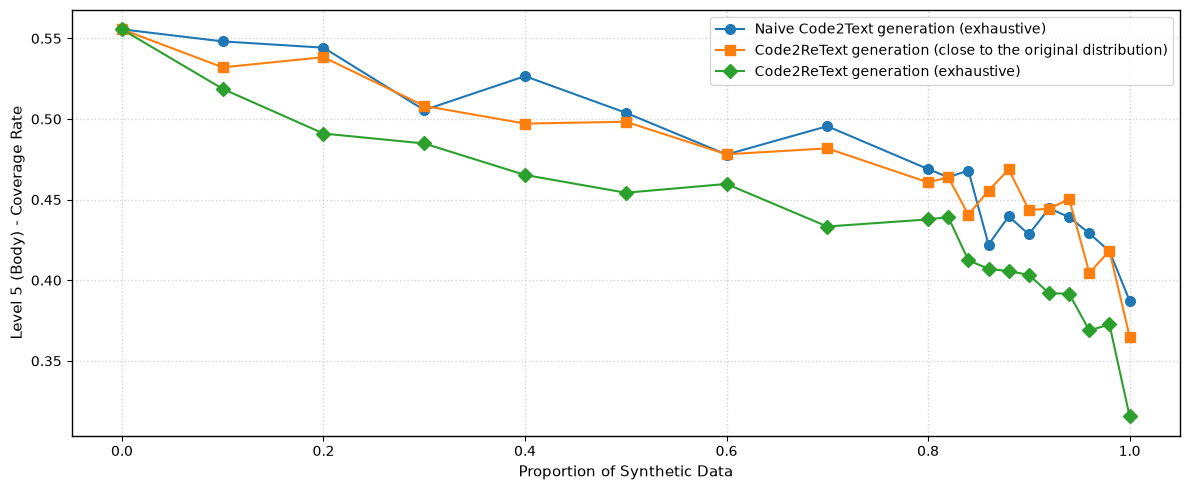

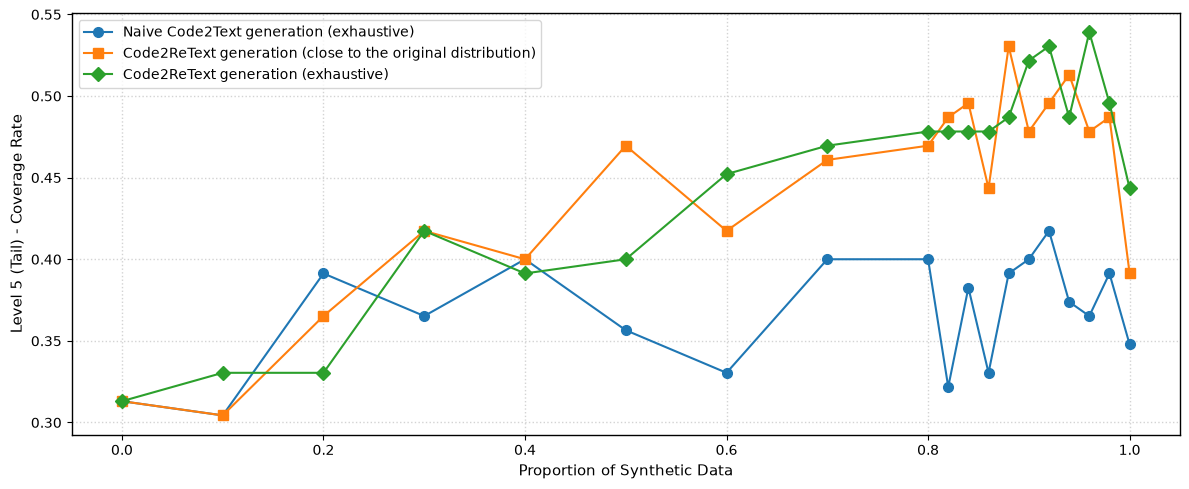

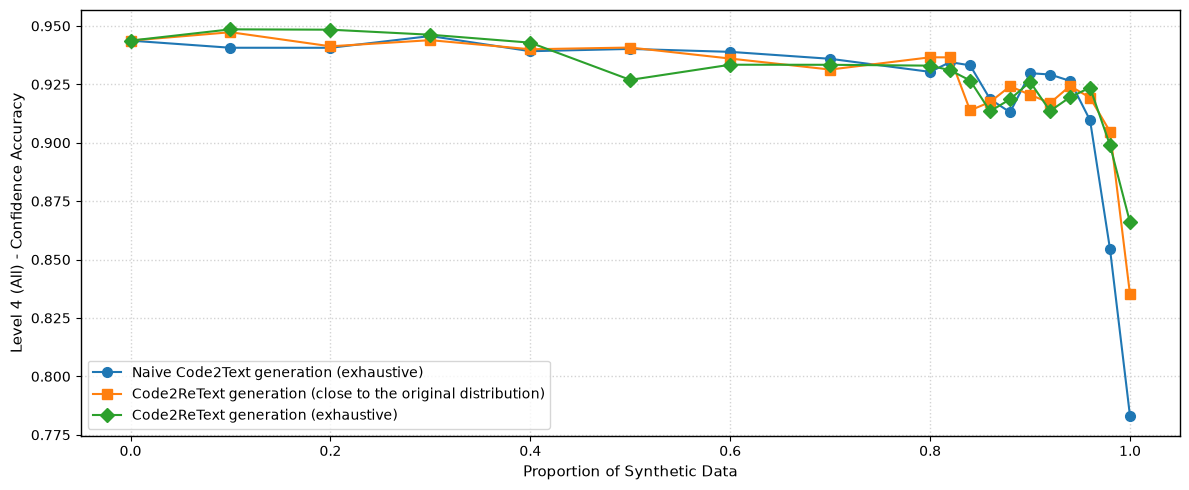

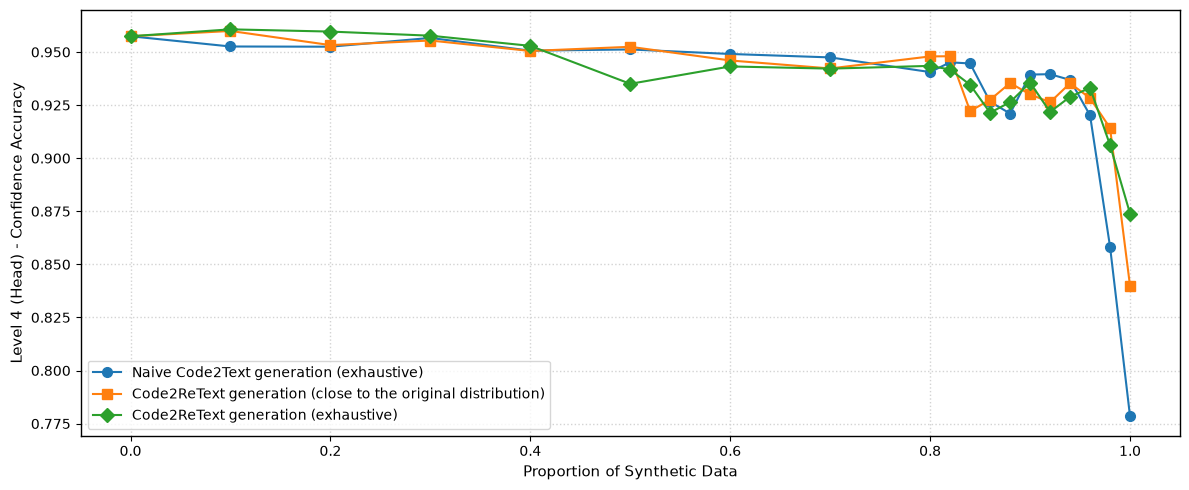

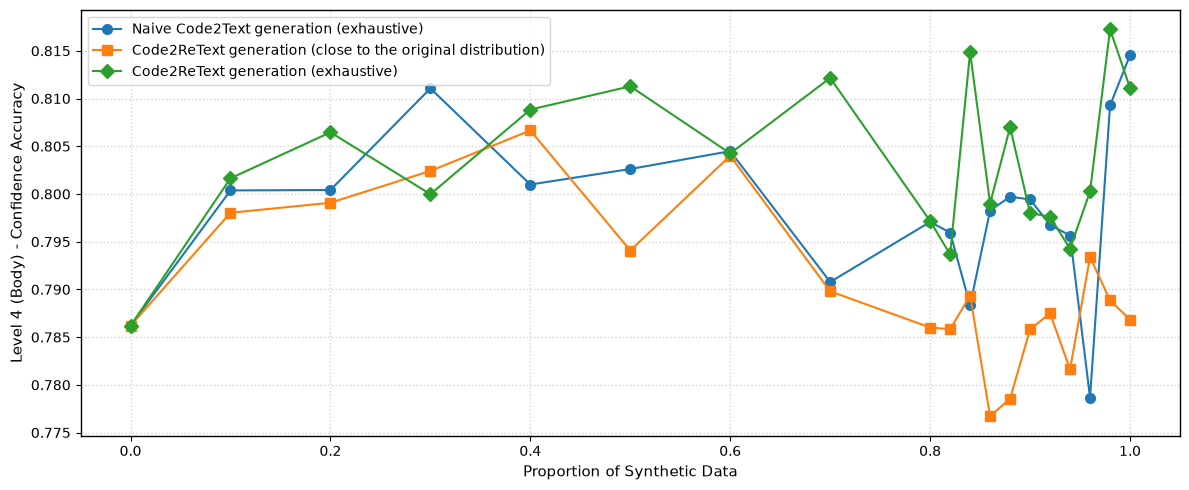

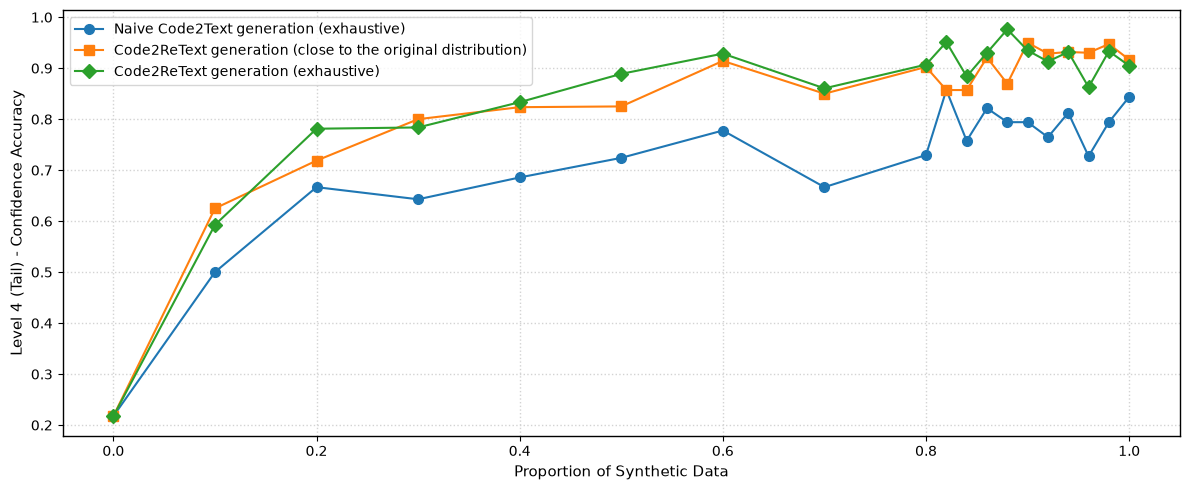

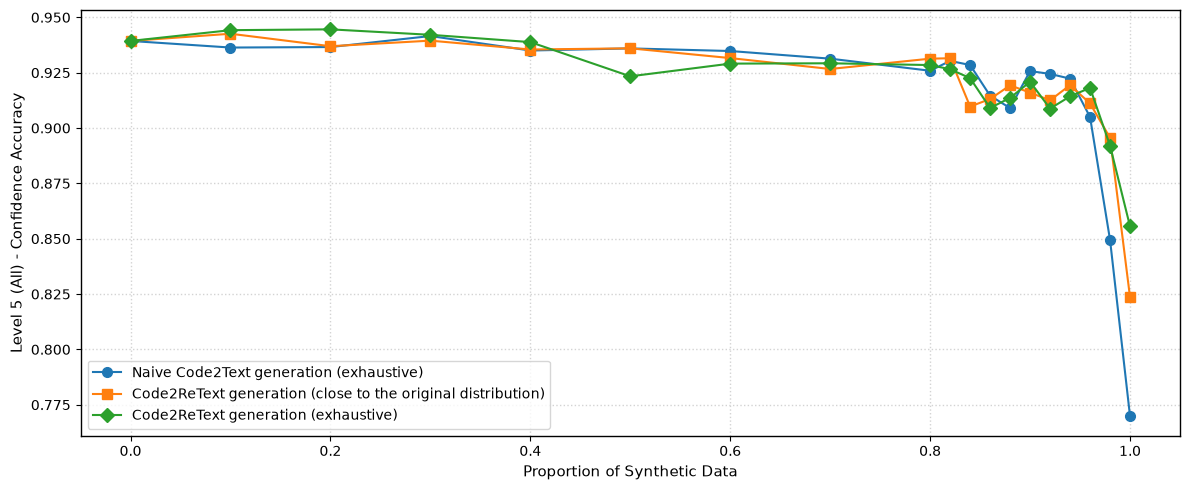

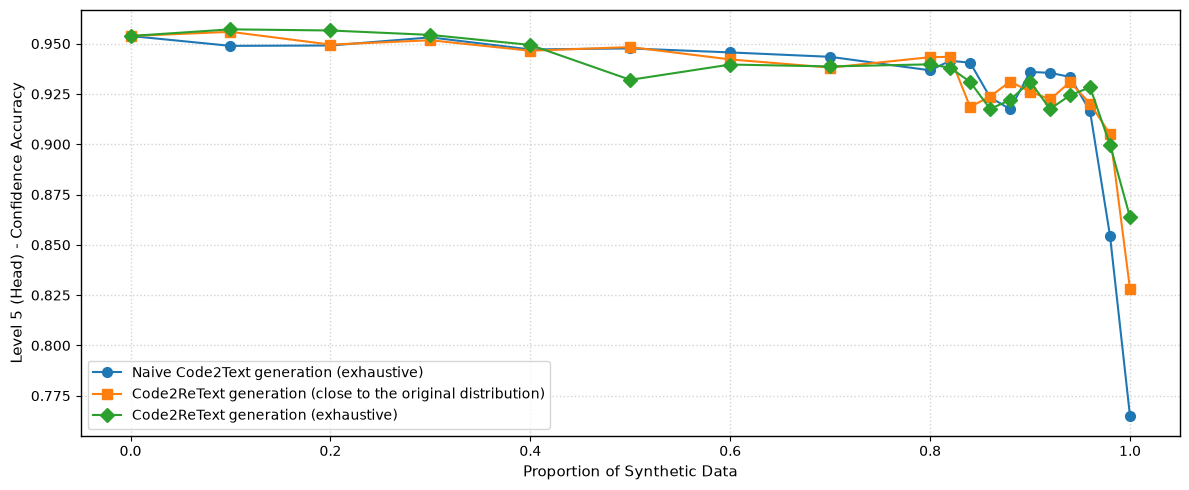

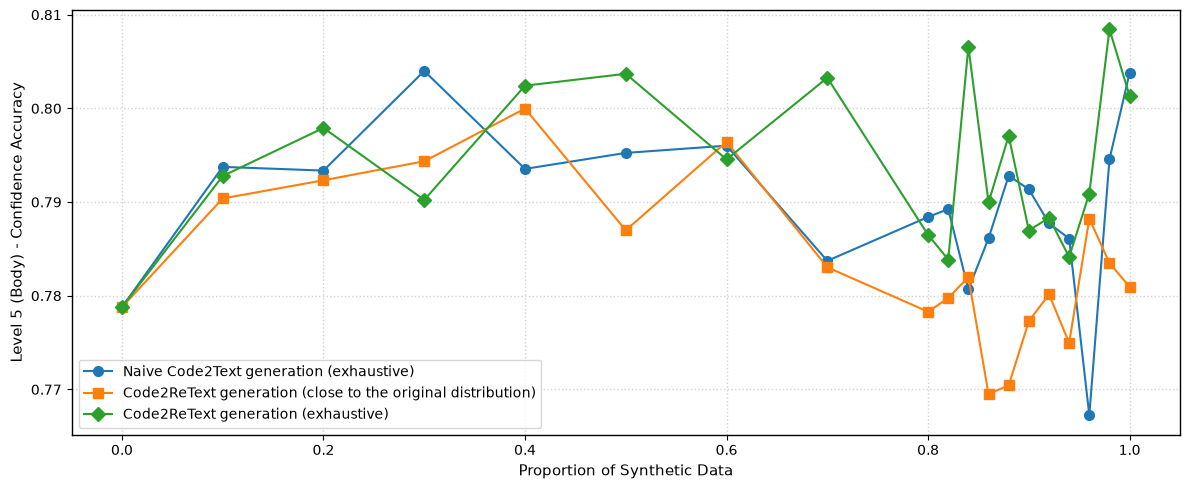

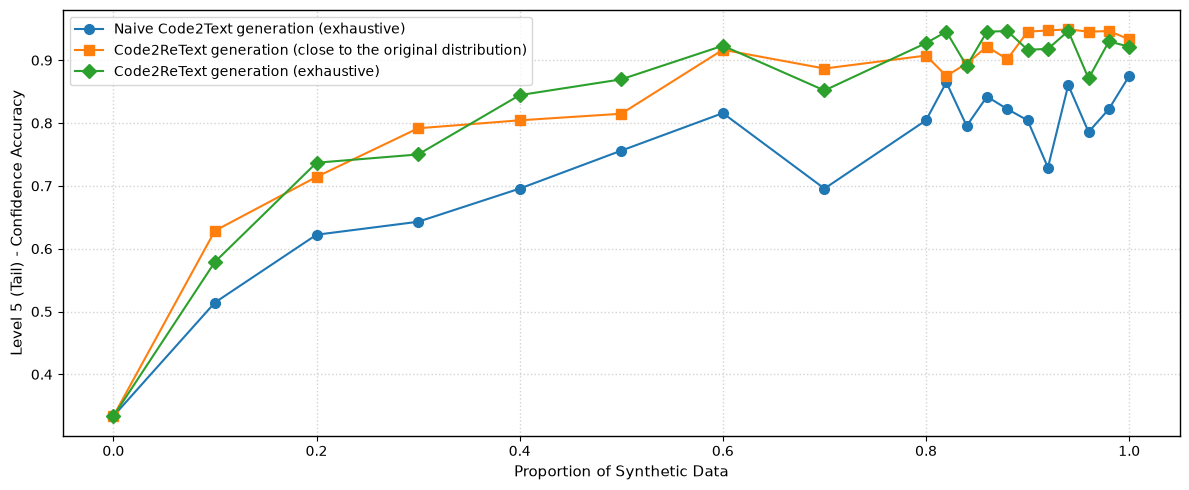

In [81]:
for metric in METRICS_COL:
    export_plot(df_graphs, "source_synth_split", metric)

In [82]:
def export_scatter_heatmap(df_graphs, x, y, z, diagonal_line=False, cmap_name="RdPu"):
    """
    Trace un scatter plot où la forme dépend de 'source_synth_name'
    et la couleur (heatmap) dépend de la colonne numérique 'z'.
    """
    df_graphs = df_graphs.sort_values(by=["source_synth_name", x])

    fig, ax = plt.subplots(figsize=(12, 5))

    markers = ['o', 's', 'D', '^']
    
    vmin = df_graphs[z].min()
    vmax = df_graphs[z].max()

    grouped = df_graphs.groupby("source_synth_name")
    
    sc = None 
    
    for i, (name, group) in enumerate(grouped):
        clean_name = map_names.get(name, name)
        marker_style = markers[i % len(markers)]
        
        sc = ax.scatter(
            group[x], 
            group[y], 
            c=group[z],
            cmap=cmap_name,
            vmin=vmin,
            vmax=vmax,
            label=clean_name,
            marker=marker_style,
            s=60,
            edgecolors='black'
        )
    
    if diagonal_line:
        line = [df_graphs[x].min(), df_graphs[x].max()]
        ax.plot(line, line, c="red", linestyle="--")

    # 3. Configuration des axes et limites
    ax.set_xlabel(map_names.get(x, x), fontsize=11)
    ax.set_ylabel(map_names.get(y, y), fontsize=11)

    ax.grid(True, which='both', color='lightgray', linestyle=':', linewidth=1)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # 4. Légende pour les formes (générée automatiquement avec des points gris/noirs neutres)
    legend = ax.legend(
        loc="best",
        frameon=True,
        facecolor='white',
        framealpha=0.7
    )
    
    # Forcer les marqueurs de la légende à avoir une couleur neutre (ex: gris foncé) 
    # pour ne pas induire en erreur sur la heatmap
    for handle in legend.legend_handles:
        handle.set_color('dimgray')

    # 5. Ajout de la Colorbar (Légende de la heatmap pour la colonne Z)
    if sc is not None:
        cbar = fig.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label(map_names.get(z, z), fontsize=11)

    plt.tight_layout()
    plt.savefig(f"heatmaps/{x}_vs_{y}_by_{z}.png")

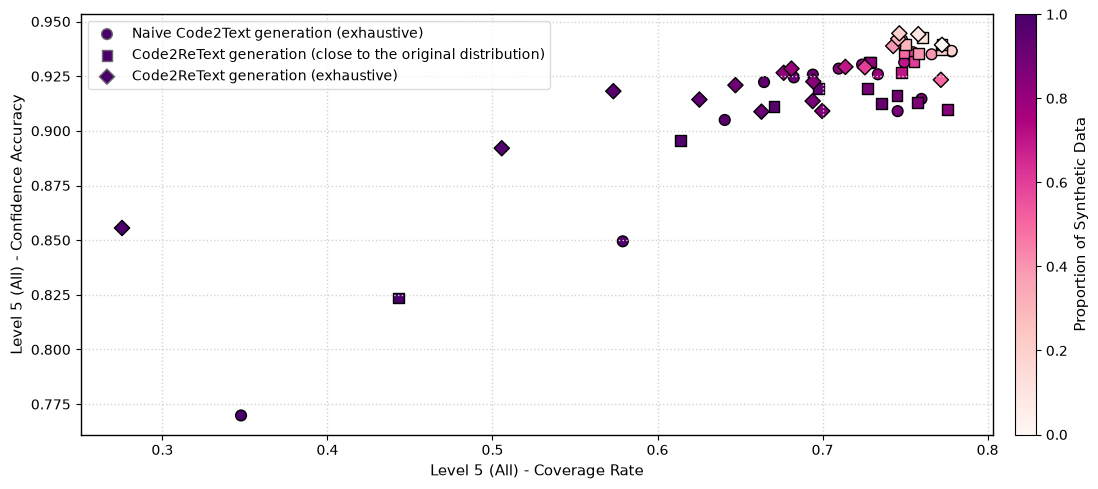

In [90]:
export_scatter_heatmap(
    df_graphs,
    x="lvl5_coverage_rate",
    y="lvl5_acc_confident",
    z="source_synth_split",
)

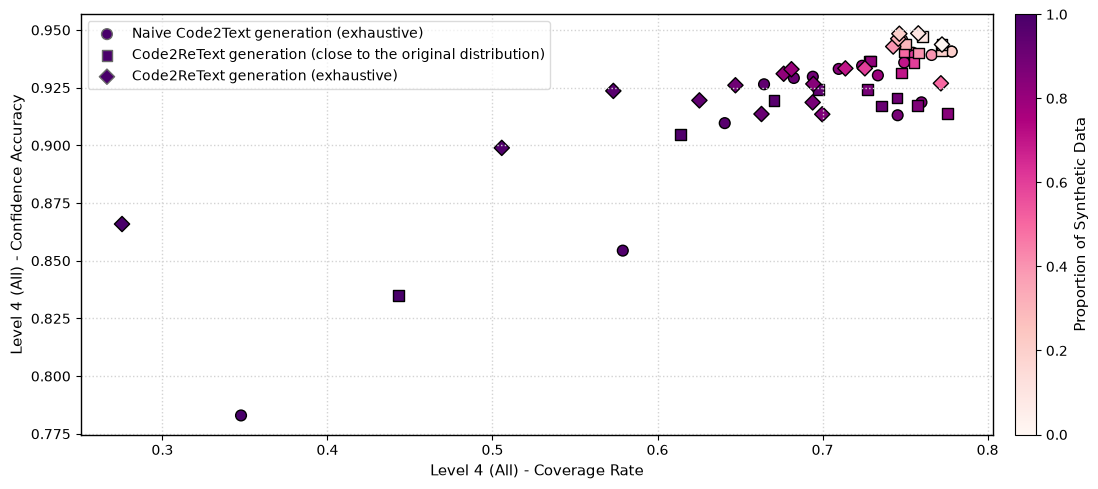

In [84]:
export_scatter_heatmap(
    df_graphs,
    x="lvl4_coverage_rate",
    y="lvl4_acc_confident",
    z="source_synth_split"
)

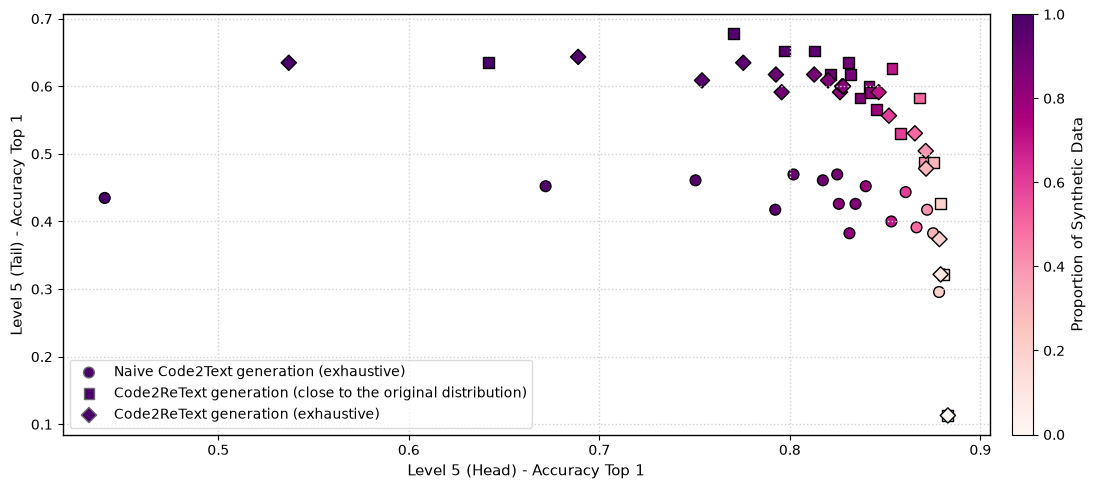

In [85]:
export_scatter_heatmap(
    df_graphs,
    x="lvl5_head_acc_top1",
    y="lvl5_tail_acc_top1",
    z="source_synth_split"
)

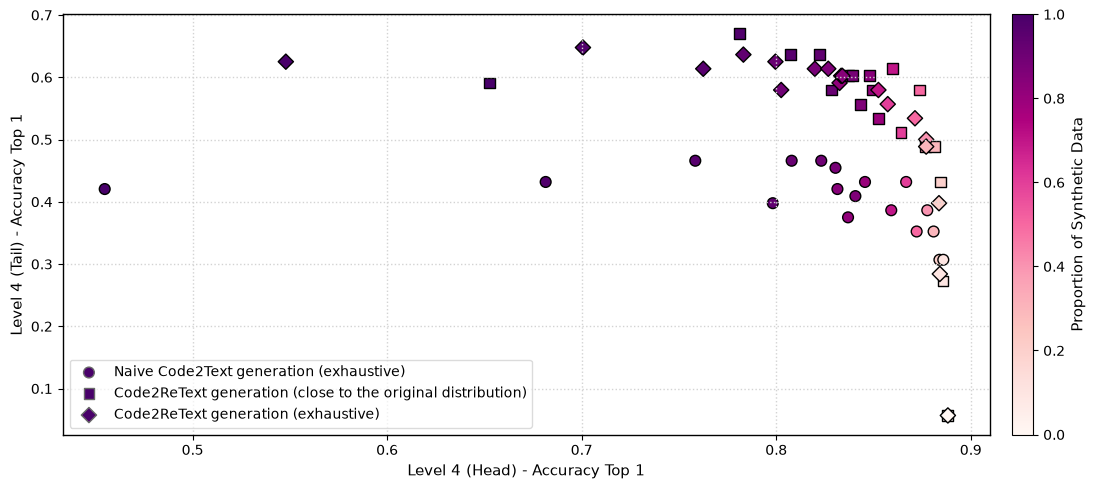

In [86]:
export_scatter_heatmap(
    df_graphs,
    x="lvl4_head_acc_top1",
    y="lvl4_tail_acc_top1",
    z="source_synth_split"
)

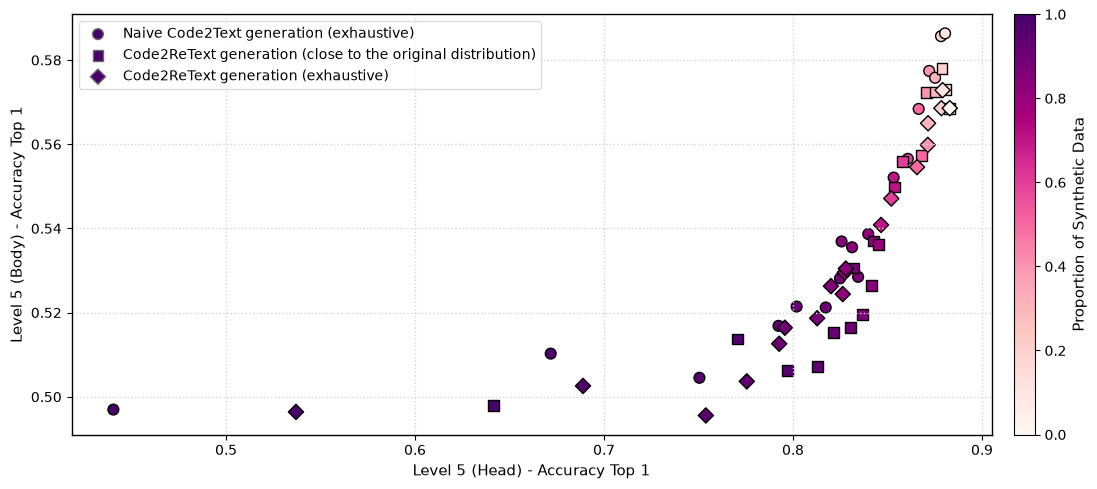

In [87]:
export_scatter_heatmap(
    df_graphs,
    x="lvl5_head_acc_top1",
    y="lvl5_body_acc_top1",
    z="source_synth_split"
)

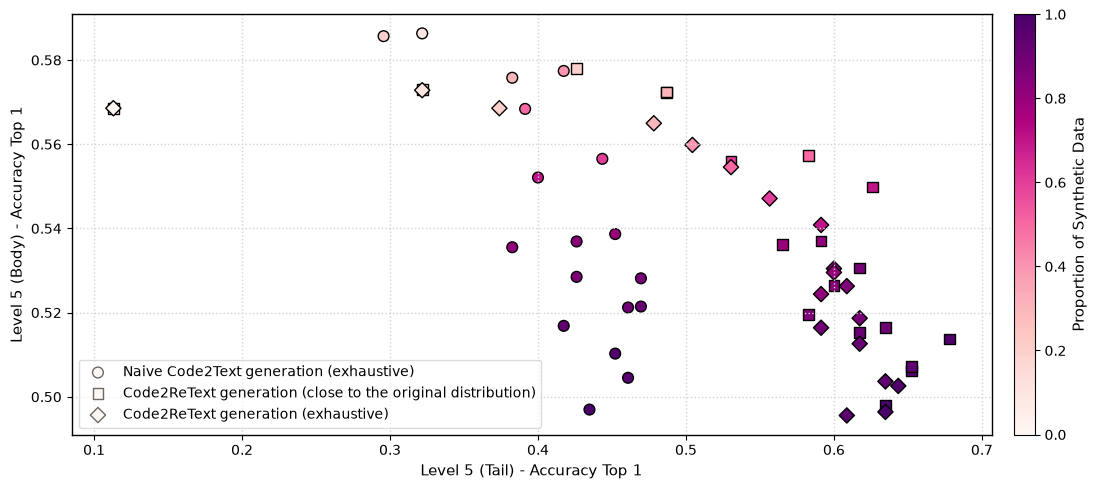

In [88]:
export_scatter_heatmap(
    df_graphs,
    x="lvl5_tail_acc_top1",
    y="lvl5_body_acc_top1",
    z="source_synth_split"
)

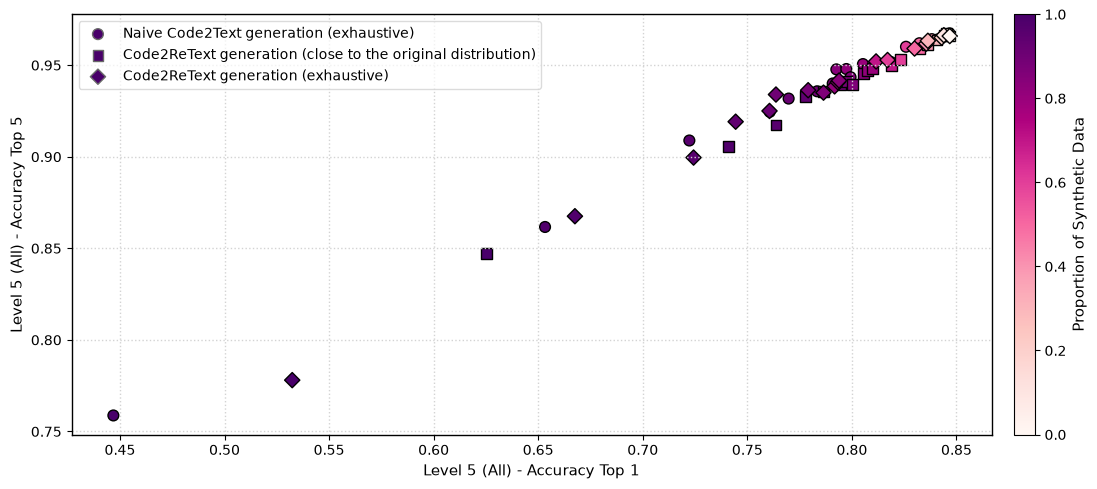

In [89]:
export_scatter_heatmap(
    df_graphs,
    x="lvl5_acc_top1",
    y="lvl5_acc_top5",
    z="source_synth_split"
)